## Energy Distribution

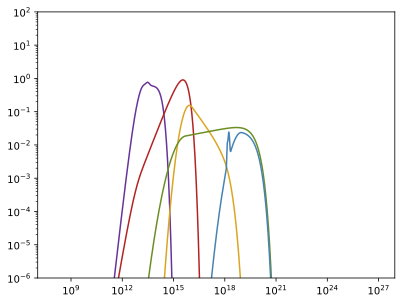

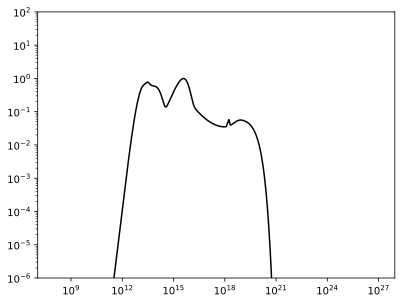

done


In [1]:
%config InlineBackend.figure_formats = ['svg']

import numpy as np
import matplotlib.pyplot as plt

# ============================================================= #
#                        Auxiliary Code                         #
# ============================================================= #

### Helper Functions ###

def lo(nu, spec, cut = 1.0, w = 0.5):
    x = np.log10(nu / cut)
    return spec * np.where(x >= 0, 1.0, np.exp(-(x**2) / (2 * w**2)))

def hi(nu, spec, cut = 1.0, w = 0.5):
    x = np.log10(nu / cut)
    return spec * np.where(x <= 0, 1.0, np.exp(-(x**2) / (2 * w**2)))


### Defining Constants ###

h = 6.626e-27
c = 2.998e10
k = 1.381e-16
G = 6.674e-8
Msun = 1.989e33
eV = 1.602e-12
keV = 1e3 * eV
sigma_SB = 5.670e-5


### Central Engine ###

Msmbh = 1e8 * Msun
lamEdd = 0.1
lumEdd = 1.26e38 * (Msmbh / Msun)
Lbol = lamEdd * lumEdd

fdisk = 0.7
Ldisk = fdisk * Lbol

Rg = G * Msmbh / c**2
Rin = 6 * Rg
Rout = 1e5 * Rg

nu = np.logspace(8, 27, 6000)


# ============================================================= #
#                       Physical Spectra                        #
# ============================================================= #

### Clumpy Dusty ###

def torus(nu, a, Tlo = 100, Thi = 1500, nT = 15, beta = 1.5, silicate = True):
    Ts = np.logspace(np.log10(Tlo), np.log10(Thi), nT)
    spec = np.zeros_like(nu)
    for T in Ts:
        contrib = nu * nu**beta * bb(nu, T)
        spec += contrib / np.nanmax(contrib)
    spec /= spec.max()

    if silicate:
        lam = c / nu * 1e4
        for lamNull, width, amp in [(9.7, 0.10, 0.25), (18.0, 0.15, 0.10)]:
            x = np.log10(lam / lamNull)
            spec *= (1 + amp * np.exp(-(x**2) / (2 * width**2)))

    return a * spec

    
### Accretion Disk ###

def bb(nu, T):
    x = h * nu / (k * np.maximum(T, 1))
    x = np.clip(x, 1e-10, 700)
    return (2 * h * nu**3 / c**2) / np.expm1(x)

def ss(r):
    Mdot = Ldisk / (0.1 * c**2)
    x = r / Rin
    prof = np.maximum(1 - x**(-1/2), 0.0)
    temp = (3 * G * Msmbh * Mdot) / (8 * np.pi * sigma_SB * r**3) * prof
    return temp**(1/4)

def disk(nu, a = 1):
    r = np.logspace(np.log10(Rin), np.log10(Rout), 101)
    dr = np.diff(r)
    r = np.sqrt(r[:-1] * r[1:])
    T = ss(r)
    Lnu = np.zeros_like(nu)
    for Ti, ri, dri in zip(T, r, dr):
        if Ti <= 10:
            continue
        Lnu += bb(nu, Ti) * ri * dri
    return a * nu * Lnu


### Soft Excess ###

def excess(nu, a, Gamma = 2.7, Ecut_keV = 6):
    E_keV = h * nu / keV
    spec = nu**(2 - Gamma) * np.exp(-E_keV / Ecut_keV)
    return a * hi(nu, lo(nu, spec, 1.2e16, 0.3), 1e18)


### Hot Corona ###

Gcor = 1.9

def corona(nu, a, Gamma = Gcor, Ecut_keV = 200):
    E_keV = h * nu / keV
    spec = nu**(2 - Gamma) * np.exp(-E_keV / Ecut_keV)
    return a * lo(nu, spec, 5e15)


### Reflected Component ###

def hump(nu, a, Gamma = Gcor, Enull_keV = 20, Ecut_keV = 180, shift = 1e21):
    E_keV = h * (nu + shift) / keV
    spec = nu**(2 - Gamma) * (E_keV / Enull_keV) * np.exp(-E_keV / Ecut_keV)
    return a * lo(1e19, lo(nu, spec, 1e19, 0.4), 0.4)

def peak(nu, a, nuNull = 1.55e18, rat = 0.3):
    nub = 1.1 * nuNull
    nur = 0.9 * nuNull
    sib = 0.10 * nuNull
    sir = np.where(nu <= nuNull * nub, 0.05 * nu, 0.01 * nu)
    lum = np.exp(-(nu - nub)**2 / (2*sib**2)) + rat * np.exp(-(nu - nur)**2 / (2*sir**2))
    return a * nu * lum
    
def reflection(nu, v, w, Gamma = Gcor, Enull_keV = 20, Ecut_keV = 180, shift = 1e21, nuNull = 1.55e18, rat = 0.4):
    return hump(nu, v, Gamma, Enull_keV, Ecut_keV, shift) + peak(nu, w, nuNull, rat)


### Radio Lobes ###

def lobe():
    return 0


### Gamma Jet ###

def jet():
    return 0




### Output Generation ###

spec = {
    'torus': torus(nu, 6e-1),
    'disk': disk(nu, 1e-43),
    'excess': excess(nu, 2.5e10),
    'corona': corona(nu, 5e-4),
    'reflection': reflection(nu, 1.7e4, 1.2e-20)
}

plt.plot(nu, spec['torus'], c='rebeccapurple')
plt.plot(nu, spec['disk'], c='firebrick')
plt.plot(nu, spec['excess'], c='goldenrod')
plt.plot(nu, spec['corona'], c='olivedrab')
plt.plot(nu, spec['reflection'], c='steelblue')

plt.ylim(1e-6, 1e2)

plt.xscale('log')
plt.yscale('log')

plt.show()




plt.plot(nu, sum(spec.values()), 'k')

plt.ylim(1e-6, 1e2)

plt.xscale('log')
plt.yscale('log')

plt.show()

print('done')